# MC-3 lab: spectral features for motion data

**Goal.** You turn a motion signal into features, train a small classifier
on them, and compare three inputs for the same task: the raw window, the
time-domain features, and the spectral features.

**Deliverable.** The table of section 8. Copy it into `report.md`.

**Time.** 50 minutes, sections 0 to 8.

**How to work.** Run the cells in order. A cell with the mark
`TODO (student)` has a task. The notebook has four tasks, and the cell
after a task checks your result. A check prints `complete` or
`not complete`.


In [1]:
import os
import platform
import sys

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"      # no start message of TensorFlow

import keras
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

tf.get_logger().setLevel("ERROR")

print("python    ", sys.version.split()[0])
print("numpy     ", np.__version__)
print("tensorflow", tf.__version__)
print("keras     ", keras.__version__)
print("machine   ", platform.machine())

RATE_HZ = 50          # samples per second
WINDOW = 100          # samples: 2 s at 50 Hz
STRIDE = 10           # samples: 0.2 s
FFT_LENGTH = 128      # the FFT length of the example
CLASSES = ["idle", "terrestrial", "lift", "maritime"]

# The lab folder. The notebook of the folder solutions/ uses the folder
# above, because the data and the code are one level up.
LAB = "." if os.path.isdir("host") and os.path.isdir("solutions") else ".."
sys.path.insert(0, os.path.join(LAB, "host"))


def recording_files(folder):
    '''Return the names of the recording files of a folder.'''
    if not os.path.isdir(folder):
        return []
    return sorted(name for name in os.listdir(folder)
                  if name.endswith(".csv") and len(name.split(".")) == 4)


DATA = os.path.join(LAB, "data")
if not recording_files(DATA):
    DATA = os.path.join(LAB, "fallback_data")
    if not recording_files(DATA):
        import make_dataset
        import motion_sim
        os.makedirs(DATA, exist_ok=True)
        for label in motion_sim.CLASSES:
            for session in make_dataset.SESSIONS:
                for number in range(1, make_dataset.RECORDINGS + 1):
                    make_dataset.write_recording(DATA, label, session,
                                                 number)
    print("No recording in the folder data/. The notebook uses the")
    print("fallback dataset. Its signals are simulated, so a model that")
    print("learns from them does not work on the real kit.")
print()
print("data folder:", os.path.normpath(DATA), "with",
      len(recording_files(DATA)), "files")


python     3.13.11
numpy      2.5.3
tensorflow 2.21.0
keras      3.15.1
machine    AMD64
No recording in the folder data/. The notebook uses the
fallback dataset. Its signals are simulated, so a model that
learns from them does not work on the real kit.

data folder: fallback_data with 48 files


## 1. Load the recordings and make the windows (4 min)

The recordings are the files of the course: one file for each recording,
a line for each sample, and the three acceleration axes in $g$. The
notebook cuts each recording into windows of 2 s, one new window every
0.2 s.

The last session is the test session. The other sessions are the training
sessions. A model that separates the sessions has learned the person and
not the motion.

You do not change this code.


In [2]:
def load_recording(path):
    '''Return the three acceleration axes of one recording, in g.'''
    values = []
    with open(path, encoding="ascii") as handle:
        for line in handle:
            if line.startswith("#") or line.startswith("n,"):
                continue
            parts = line.split(",")
            values.append([float(parts[2]), float(parts[3]),
                           float(parts[4])])
    return np.array(values, dtype=np.float32)


def windows_of(names):
    '''Return the windows of the given files: X has the shape
    (number of windows, WINDOW, 3) and y has the class of each window.'''
    x, y = [], []
    for name in names:
        label = name.split(".")[0]
        data = load_recording(os.path.join(DATA, name))
        for start in range(0, len(data) - WINDOW + 1, STRIDE):
            x.append(data[start:start + WINDOW])
            y.append(CLASSES.index(label))
    return np.array(x, dtype=np.float32), np.array(y, dtype="int32")


sessions = sorted({name.split(".")[1] for name in recording_files(DATA)})
test_session = sessions[-1]
train_names = [n for n in recording_files(DATA)
               if n.split(".")[1] != test_session]
test_names = [n for n in recording_files(DATA)
              if n.split(".")[1] == test_session]
X_train, y_train = windows_of(train_names)
X_test, y_test = windows_of(test_names)

print("sessions          ", sessions)
print("test session      ", test_session)
print("training windows  ", X_train.shape, "from", len(train_names),
      "files")
print("test windows      ", X_test.shape, "from", len(test_names),
      "files")
for k, label in enumerate(CLASSES):
    print("  %-12s %5d training, %5d test"
          % (label, int((y_train == k).sum()), int((y_test == k).sum())))


sessions           ['s1', 's2', 's3']
test session       s3
training windows   (1312, 100, 3) from 32 files
test windows       (656, 100, 3) from 16 files
  idle           328 training,   164 test
  terrestrial    328 training,   164 test
  lift           328 training,   164 test
  maritime       328 training,   164 test


## 2. Time-domain features (10 min)

**Task 1.** Write `time_features(window)`. It takes the values of one axis
of one window and returns three values: the root mean square, the
skewness, and the kurtosis. Remove the mean of the window first.

The three functions of the cell are given. Their formulas use no
correction for the sample size, so the same window always gives the same
values on a laptop and on a board.


In [3]:
def remove_mean(x):
    '''Return the signal after the removal of its mean.'''
    return x - x.mean()


def rms(x):
    '''Return the root mean square of a signal.'''
    return float(np.sqrt(np.mean(np.square(x))))


def skewness(x):
    '''Return the skewness of a signal, with no correction for the
    sample size.'''
    s = x.std()
    if s == 0.0:
        return 0.0
    return float(np.mean(((x - x.mean()) / s) ** 3))


def kurtosis(x):
    '''Return the kurtosis of a signal, with no correction for the
    sample size. The value of a normal distribution is 0.'''
    s = x.std()
    if s == 0.0:
        return 0.0
    return float(np.mean(((x - x.mean()) / s) ** 4) - 3.0)


In [4]:
# Task 1: the three time-domain features of one axis.
def time_features(window):
    '''Return the RMS, the skewness, and the kurtosis of one axis of one
    window, in that order. The answer has three values.'''
    centred = remove_mean(window)
    return np.array([rms(centred), skewness(centred), kurtosis(centred)],
                    dtype=np.float32)


In [5]:
def check_task_1():
    '''Print the result of task 1. The expected value comes from the
    functions of the cell above, not from the answer.'''
    window = X_train[0, :, 0]
    centred = remove_mean(window)
    expected = np.array([rms(centred), skewness(centred), kurtosis(centred)])
    got = np.asarray(time_features(window), dtype=float)
    ok = got.shape == (3,) and np.allclose(got, expected, atol=1e-6)
    print("Task 1:", "complete" if ok else "not complete")
    if got.shape == (3,):
        print("  rms %.4f  skewness %.4f  kurtosis %.4f" % tuple(got))
    else:
        print("  the answer must have three values, it has",
              got.shape, "values")


check_task_1()


Task 1: complete
  rms 0.0038  skewness -0.3266  kurtosis -0.0771


## 3. Spectral features (12 min)

The FFT of a window gives the power at each frequency. The window of
2 s has 100 samples, and the FFT length of 128 pads it with zeros. The
distance between two bins is then $f_s / N = 50 / 128 = 0.39$ Hz. Bin 0
holds the mean of the window, which is zero now, so the answer starts at
bin 1.

The plot shows the power of the first window of each class, on the z axis
and from 0 to 4 Hz. The FFT still gives 64 bins, but no class of this
module moves faster than 4 Hz, so the plot stops there.

`lift` and `maritime` each move at their own rate, so each one puts its
power in a band of its own. `idle` has no band at all, because it does not
move. The z axis of `terrestrial` is almost still, because the motion of a
truck sits in the horizontal plane, on the axes x and y. That is the
reason why the feature vector holds the three axes and not one.

**Task 2.** Write `axis_features(window, nfft)`. It returns the three
time-domain features first, then the power of bins 1 to `nfft // 2`. The
answer has `3 + nfft // 2` values.


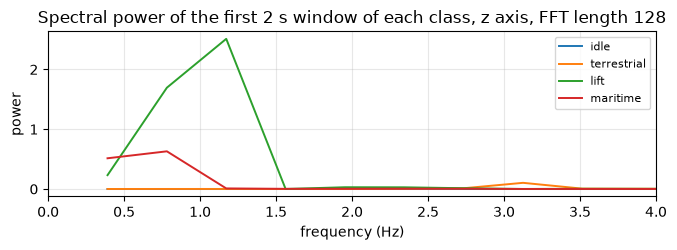

In [6]:
def spectral_power(window, nfft):
    '''Return the power of bins 1 to nfft // 2 of one axis. The mean of
    the window is removed first, so bin 0 carries nothing.'''
    spectrum = np.fft.rfft(remove_mean(window), nfft)
    return (np.abs(spectrum) ** 2 / nfft)[1:].astype(np.float32)


plt.figure(figsize=(7.0, 2.6))
for k, label in enumerate(CLASSES):
    index = int(np.argmax(y_train == k))
    power = spectral_power(X_train[index, :, 2], FFT_LENGTH)
    frequency = np.arange(1, len(power) + 1) * RATE_HZ / FFT_LENGTH
    plt.plot(frequency, power, label=label, linewidth=1.4)
plt.xlabel("frequency (Hz)")
plt.ylabel("power")
plt.title("Spectral power of the first 2 s window of each class, z axis, "
          "FFT length %d" % FFT_LENGTH)
plt.xlim(0, 4)
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [7]:
# Task 2: the features of one axis.
def axis_features(window, nfft=FFT_LENGTH):
    '''Return the three time-domain features of one axis, then the power
    of bins 1 to nfft // 2. The answer has 3 + nfft // 2 values.'''
    return np.concatenate([time_features(window),
                           spectral_power(window, nfft)])


In [8]:
def build_features(windows, nfft=FFT_LENGTH):
    '''Return the feature matrix: one row for each window, the three axes
    in order. The matrix has 3 * (3 + nfft // 2) columns.'''
    rows = []
    for window in windows:
        rows.append(np.concatenate([axis_features(window[:, k], nfft)
                                    for k in range(windows.shape[2])]))
    return np.array(rows, dtype=np.float32)


def build_time_features(windows):
    '''Return the time-domain features only: 9 columns.'''
    rows = []
    for window in windows:
        rows.append(np.concatenate([time_features(window[:, k])
                                    for k in range(windows.shape[2])]))
    return np.array(rows, dtype=np.float32)


In [9]:
def check_task_2():
    '''Print the result of task 2. The expected value comes from the
    functions of the cells above, not from the answer.'''
    window = X_train[0, :, 0]
    nfft = FFT_LENGTH
    expected = np.concatenate([
        np.array([rms(remove_mean(window)), skewness(remove_mean(window)),
                  kurtosis(remove_mean(window))]),
        spectral_power(window, nfft)])
    got = np.asarray(axis_features(window, nfft), dtype=float)
    ok = (got.shape == (3 + nfft // 2,)
          and np.allclose(got, expected, atol=1e-6))
    print("Task 2:", "complete" if ok else "not complete")
    print("  the answer has", got.shape[0], "values, the table of the")
    print("  features of one axis needs", 3 + nfft // 2)
    if got.shape == (3 + nfft // 2,):
        print("  rms %.4f  power of bin 1 %.3g  power of bin 2 %.3g"
              % (got[0], got[3], got[4]))


check_task_2()


Task 2: complete
  the answer has 67 values, the table of the
  features of one axis needs 67
  rms 0.0038  power of bin 1 4.86e-06  power of bin 2 3.28e-07


## 4. Normalize the features (3 min)

The features have very different sizes: the power of a bin can be large,
and the skewness is near 1. The mean and the standard deviation of each
feature come from the training windows only. The test windows use the
same two values.

You do not change this code.


In [10]:
def normalize(train, test):
    '''Return the two matrices, each column scaled with the mean and the
    standard deviation of the training columns.'''
    mean = train.mean(axis=0)
    std = train.std(axis=0)
    std[std == 0.0] = 1.0
    return (train - mean) / std, (test - mean) / std, mean, std


X_feature_train, X_feature_test, MEAN, STD = normalize(
    build_features(X_train), build_features(X_test))
print("feature matrix, training:", X_feature_train.shape)
print("feature matrix, test    :", X_feature_test.shape)
print("mean of the first nine features:",
      np.array2string(MEAN[:9], precision=2))
print("standard deviation of the first nine features:",
      np.array2string(STD[:9], precision=2))


feature matrix, training: (1312, 201)
feature matrix, test    : (656, 201)
mean of the first nine features: [ 0.1   0.02 -1.04  0.35  0.2   0.24  0.04  0.01  0.01]
standard deviation of the first nine features: [0.08 0.2  0.7  0.62 0.23 0.52 0.09 0.02 0.01]


## 5. The classifier (8 min)

**Task 3.** Write `make_model(n_inputs)`. Three dense layers: 20 units
with ReLU, 10 units with ReLU, and 4 outputs with softmax.

Give the layers the names `dense`, `dense_1`, and `dense_2`, and the
input the name `keras_tensor`. Without the names, the size of the file
of the model changes with each model that the notebook builds.


In [11]:
# Task 3: the classifier.
def make_model(n_inputs):
    '''Return a model with 20 units, then 10 units, then 4 outputs with
    softmax.'''
    inputs = keras.Input(shape=(n_inputs,), dtype="float32",
                        name="keras_tensor")
    hidden = keras.layers.Dense(20, activation="relu",
                                name="dense")(inputs)
    hidden = keras.layers.Dense(10, activation="relu",
                                name="dense_1")(hidden)
    outputs = keras.layers.Dense(len(CLASSES), activation="softmax",
                                 name="dense_2")(hidden)
    return keras.Model(inputs=inputs, outputs=outputs, name="sequential")


In [12]:
def check_task_3():
    '''Print the result of task 3 and return True when the answer is
    right. The expected number of parameters is calculated by the check
    itself. The cells that train a model do nothing until this check
    passes.'''
    n_inputs = X_feature_train.shape[1]
    expected = n_inputs * 20 + 20 + 20 * 10 + 10 + 10 * 4 + 4
    try:
        model = make_model(n_inputs)
        params = model.count_params()
        output = model.output_shape[-1]
    except Exception as error:                # noqa: BLE001
        print("Task 3: not complete")
        print("  the model raises an error:", error)
        return False
    ok = params == expected and output == len(CLASSES)
    print("Task 3:", "complete" if ok else "not complete")
    print("  input values %d, parameters %d (expected %d), outputs %d"
          % (n_inputs, params, expected, output))
    return ok


MODEL_COMPLETE = check_task_3()


Task 3: complete
  input values 201, parameters 4294 (expected 4294), outputs 4


In [13]:
def percent(value):
    '''Return a test accuracy for the report, or the text that says that
    the number was not measured.'''
    return ("not measured" if value != value
            else "%.1f percent" % (100 * value))


def fit_and_score(x_train, x_test, epochs=100):
    '''Train a small classifier and return the test accuracy and the
    number of parameters. Every call starts from the same seed. The
    cell does nothing until the check of task 3 passes.'''
    if not MODEL_COMPLETE:
        return float("nan"), 0
    keras.utils.set_random_seed(0)
    model = make_model(x_train.shape[1])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    model.fit(x_train, y_train, epochs=epochs, batch_size=32, verbose=0,
              shuffle=True)
    scores = model.evaluate(x_test, y_test, verbose=0)
    return float(scores[1]), model.count_params()


accuracy_feature, parameters_feature = fit_and_score(X_feature_train,
                                                     X_feature_test)
print("the model on the spectral features: %d parameters, test accuracy %s"
      % (parameters_feature, percent(accuracy_feature)))


the model on the spectral features: 4294 parameters, test accuracy 98.8 percent


## 6. Three inputs for the same task (8 min)

The notebook trains the same network three times:

1. the raw window, 300 values with no processing;
2. the time-domain features only, 9 values;
3. the spectral features, 201 values.

You do not change this code. Read the three lines of output and answer
the questions of `report.md`.


In [14]:
raw_train, raw_test, _, _ = normalize(X_train.reshape(len(X_train), -1),
                                       X_test.reshape(len(X_test), -1))
time_train, time_test, _, _ = normalize(build_time_features(X_train),
                                        build_time_features(X_test))

accuracy_raw, parameters_raw = fit_and_score(raw_train, raw_test)
accuracy_time, parameters_time = fit_and_score(time_train, time_test)

print("raw window          : %3d values, %5d parameters, test accuracy %s"
      % (raw_train.shape[1], parameters_raw, percent(accuracy_raw)))
print("time-domain features: %3d values, %5d parameters, test accuracy %s"
      % (time_train.shape[1], parameters_time, percent(accuracy_time)))
print("spectral features   : %3d values, %5d parameters, test accuracy %s"
      % (X_feature_train.shape[1], parameters_feature,
         percent(accuracy_feature)))


raw window          : 300 values,  6274 parameters, test accuracy 58.5 percent
time-domain features:   9 values,   454 parameters, test accuracy 100.0 percent
spectral features   : 201 values,  4294 parameters, test accuracy 98.8 percent


## 7. The FFT length (10 min)

The FFT length decides two things at the same time: the number of bins,
and the distance between two bins. A small length gives a small feature
vector, and it puts several motions in the same bin.

**Task 4.** Before you run the next cell, complete the table with the
number of values that one axis has for each FFT length. Then write the
length that you expect to give the best test accuracy, and why.


In [15]:
# Task 4: the number of values of one axis is 3 plus the number of bins,
# and the number of bins is nfft // 2.
feature_count = {32: 3 + 32 // 2, 64: 3 + 64 // 2, 128: 3 + 128 // 2}
best_fft_length = 128
best_fft_reason = ("the classes move below 2 Hz, and only a long FFT "
                   "gives bins below 1 Hz")


In [16]:
rows_fft = []
for nfft in (32, 64, 128):
    train = build_features(X_train, nfft)
    test = build_features(X_test, nfft)
    train, test, _, _ = normalize(train, test)
    accuracy, parameters = fit_and_score(train, test)
    rows_fft.append((nfft, 3 * (3 + nfft // 2), parameters,
                     100 * accuracy))
    print("FFT length %3d: %3d values, %5d parameters, test accuracy %s"
          % (rows_fft[-1][0], rows_fft[-1][1], rows_fft[-1][2],
             percent(accuracy)))


FFT length  32:  57 values,  1414 parameters, test accuracy 99.2 percent


FFT length  64: 105 values,  2374 parameters, test accuracy 100.0 percent


FFT length 128: 201 values,  4294 parameters, test accuracy 98.8 percent


In [17]:
def check_task_4():
    '''Print the result of task 4. The check calculates the number of
    values itself.'''
    ok = (sorted(feature_count) == [32, 64, 128]
          and all(feature_count[n] == 3 + n // 2 for n in feature_count)
          and best_fft_length in (32, 64, 128)
          and len(str(best_fft_reason).split()) >= 5)
    print("Task 4:", "complete" if ok else "not complete")
    print("  values of one axis:", feature_count)
    print("  the length you expect:", best_fft_length)
    measured = [row for row in rows_fft if row[3] == row[3]]
    if len(measured) == len(rows_fft) and measured:
        best = max(measured, key=lambda row: row[3])
        print("  the length that wins in this run:", best[0],
              "with %s" % percent(best[3] / 100))


check_task_4()


Task 4: complete
  values of one axis: {32: 19, 64: 35, 128: 67}
  the length you expect: 128
  the length that wins in this run: 64 with 100.0 percent


## 8. The table for the report (3 min)

Copy this table into `report.md`. Then answer the three questions of the
report. Use the numbers of your run, not the numbers of this text.


In [18]:
table = [("raw window", raw_train.shape[1], parameters_raw, accuracy_raw),
         ("time-domain features", time_train.shape[1], parameters_time,
          accuracy_time),
         ("spectral features", X_feature_train.shape[1],
          parameters_feature, accuracy_feature)]
table += [("spectral features, FFT %d" % row[0], row[1], row[2],
           row[3] / 100) for row in rows_fft if row[0] != FFT_LENGTH]

print("| Input | Values | Parameters | Test accuracy |")
print("|---|---|---|---|")
for name, values, parameters, accuracy in table:
    print("| %s | %d | %d | %s |" % (name, values, parameters,
                                     percent(accuracy)))
print()
print("The accuracy is on the windows of the session %s. The values of"
      % test_session)
print("one window come from a laptop CPU, not from a board.")

# The file that the figure script of the course repository reads.
import json
results = {"rate_hz": RATE_HZ, "window": WINDOW, "fft_length": FFT_LENGTH,
           "test_session": test_session,
           "inputs": [{"name": name, "values": values,
                       "parameters": parameters,
                       "accuracy": accuracy}
                      for name, values, parameters, accuracy in table]}
with open(os.path.join(LAB, "results.json"), "w", encoding="utf-8") as f:
    json.dump(results, f, indent=1)
print()
print("The notebook wrote results.json for the figures of the deck.")


| Input | Values | Parameters | Test accuracy |
|---|---|---|---|
| raw window | 300 | 6274 | 58.5 percent |
| time-domain features | 9 | 454 | 100.0 percent |
| spectral features | 201 | 4294 | 98.8 percent |
| spectral features, FFT 32 | 57 | 1414 | 99.2 percent |
| spectral features, FFT 64 | 105 | 2374 | 100.0 percent |

The accuracy is on the windows of the session s3. The values of
one window come from a laptop CPU, not from a board.

The notebook wrote results.json for the figures of the deck.


## Questions for `report.md`

1. Which input gives the smallest model, and how many parameters does it
   save compared with the raw window?
2. Which input gives the best test accuracy, and which feature group
   explains the difference?
3. The bins of the FFT are `nfft // 2` values apart by `RATE_HZ / nfft`
   hertz. Write that distance for the FFT length that won, and name the
   frequency of the motion that the bins of a length of 32 cannot show.
